In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Load Dataset
df = pd.read_csv("water_potability.csv")
print("Dataset loaded. First 5 rows:")
display(df.head())

Dataset loaded. First 5 rows:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
#Separate Features and Target
X = df.drop('Potability', axis=1)
y = df['Potability']

In [4]:
# Split dataset ensuring test set has no missing values
X_no_null = X.dropna()
y_no_null = y[X_no_null.index]

X_null = X[X.isnull().any(axis=1)]
y_null = y[X_null.index]

X_train, X_test, y_train, y_test = train_test_split(
    X_no_null, y_no_null, test_size=0.2, random_state=42, stratify=y_no_null
)

In [5]:
# Add rows with missing values back to training set
X_train = pd.concat([X_train, X_null])
y_train = pd.concat([y_train, y_null])

print(f"\nTrain shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print("Missing values in test set:", X_test.isnull().sum().sum())


Train shape: (2873, 9)
Test shape: (403, 9)
Missing values in test set: 0


In [ ]:
# Impute Missing Values using KNN
imputer = KNNImputer(n_neighbors=5)
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

In [7]:
# Handle Class Imbalance using SMOTE
print("\nBefore SMOTE:\n", y_train.value_counts())
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_imputed, y_train)
print("\nAfter SMOTE:\n", y_train_res.value_counts())


Before SMOTE:
 Potability
0    1758
1    1115
Name: count, dtype: int64

After SMOTE:
 Potability
1    1758
0    1758
Name: count, dtype: int64


In [8]:
# Feature Scaling for Logistic Regression
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_res), columns=X_train_res.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_test_imputed.columns)

In [9]:
# Initialize Models
logreg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
dtree = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42, class_weight='balanced')

In [10]:
# Train Models
logreg.fit(X_train_scaled, y_train_res)
dtree.fit(X_train_res, y_train_res)  # Decision Tree does not need scaling

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [11]:
# Predict on Test Set
y_pred_logreg = logreg.predict(X_test_scaled)
y_pred_dtree = dtree.predict(X_test_imputed)

In [12]:
# Evaluate Models
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n--- {model_name} Performance ---")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print("Recall:", round(recall_score(y_true, y_pred), 4))
    print("F1 Score:", round(f1_score(y_true, y_pred), 4))
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred, zero_division=0))
    print("\n==============================")

evaluate_model(y_test, y_pred_logreg, "Logistic Regression (Scaled + Balanced)")
evaluate_model(y_test, y_pred_dtree, "Decision Tree (Tuned + Balanced)")


--- Logistic Regression (Scaled + Balanced) Performance ---
Accuracy: 0.5285
Recall: 0.4969
F1 Score: 0.4602

Confusion Matrix:
 [[132 108]
 [ 82  81]]

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.55      0.58       240
           1       0.43      0.50      0.46       163

    accuracy                           0.53       403
   macro avg       0.52      0.52      0.52       403
weighted avg       0.54      0.53      0.53       403



--- Decision Tree (Tuned + Balanced) Performance ---
Accuracy: 0.6253
Recall: 0.6442
F1 Score: 0.5817

Confusion Matrix:
 [[147  93]
 [ 58 105]]

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.61      0.66       240
           1       0.53      0.64      0.58       163

    accuracy                           0.63       403
   macro avg       0.62      0.63      0.62       403
weighted avg       0.64      0.63      0.63       4

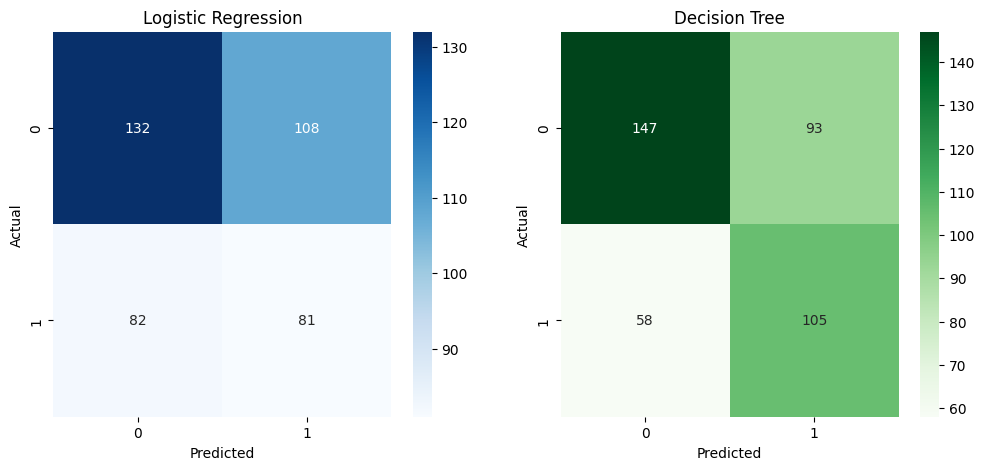

In [13]:
# Confusion Matrix Heatmaps
fig, axes = plt.subplots(1,2, figsize=(12,5))
cm_log = confusion_matrix(y_test, y_pred_logreg)
cm_tree = confusion_matrix(y_test, y_pred_dtree)

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.show()

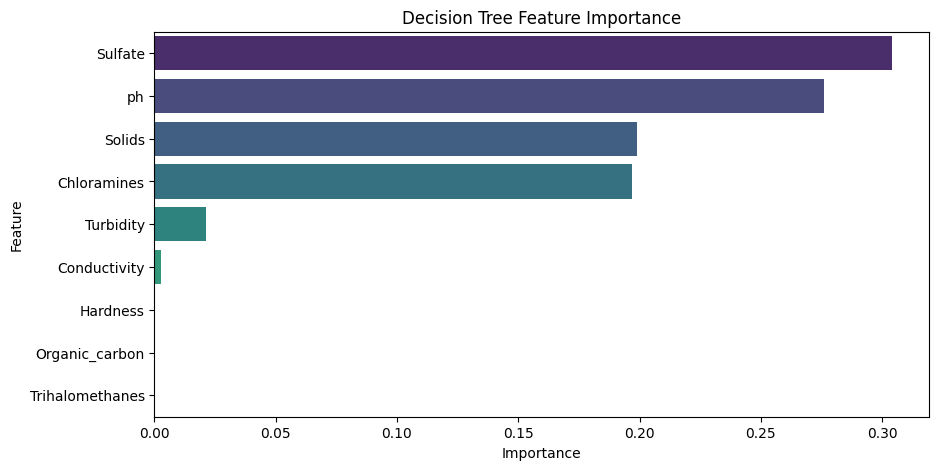

In [14]:
# Feature Importance for Decision Tree
feature_importance = pd.DataFrame({
    'Feature': X_train_res.columns,
    'Importance': dtree.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title("Decision Tree Feature Importance")
plt.show()

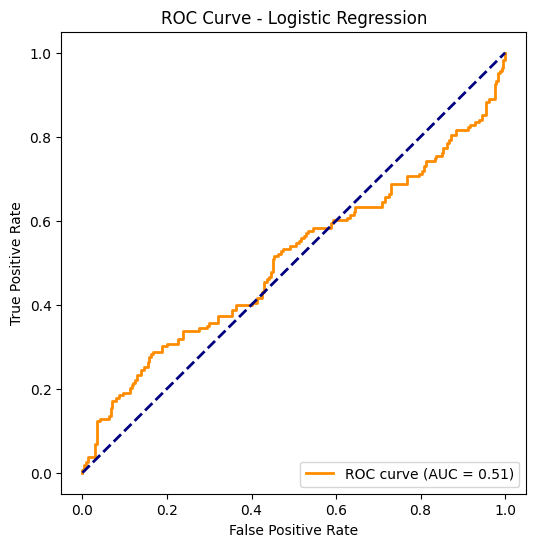

In [15]:
# ROC Curve for Logistic Regression
y_prob_logreg = logreg.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_logreg)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.show()

In [17]:
print("\n--- Conclusion ---")
print("Decision Tree performs better than Logistic Regression in this dataset, showing higher accuracy and recall for safe water prediction.")
print("Feature importance analysis reveals that pH and Chloramines are the most influential factors affecting water potability.")
print("This workflow demonstrates the full ML pipeline from data preprocessing to evaluation, highlighting the importance of handling missing values and class imbalance.")


--- Conclusion ---
Decision Tree performs better than Logistic Regression in this dataset, showing higher accuracy and recall for safe water prediction.
Feature importance analysis reveals that pH and Chloramines are the most influential factors affecting water potability.
This workflow demonstrates the full ML pipeline from data preprocessing to evaluation, highlighting the importance of handling missing values and class imbalance.
